# Task 2 Regression

In [1]:
import matplotlib.pyplot as plt, numpy as np, os, torch, random, cv2, json
from torch import nn
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F
from torchvision import models
from torchvision.transforms import v2 as transforms
from tqdm import tqdm
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

random.seed(42)

input_path = "/kaggle/input/chessred2k-altered-2"
save_dir = "/kaggle/working/"
annotations_dir = "altered_annotations_2.json"

## Load dataset

**Tip**: since the images are very big, resize the dataset before loading it to save time and memory during training (use cubic interpolation to preserve image quality when downsizing the images)!

In [ ]:
# Normalize images
data_aug = transforms.Compose([
    transforms.ToImage(),
    transforms.Resize((224, 224)), # to align with previous post center-crop size
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 0.15)),
    transforms.ToDtype(torch.float32, scale=True),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

data_in = transforms.Compose([
    transforms.ToImage(),
    transforms.Resize((224, 224)), # to align with previous post center-crop size
    transforms.ToDtype(torch.float32, scale=True),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


In [3]:
def chesspos2number(chesspos):
    col = ord(chesspos[0])-ord('a')
    row = int(chesspos[1])-1
    return row, col

class ChessDataset(Dataset):
    def __init__(self, root_dir, partition, transform=None):
        self.anns = json.load(open(os.path.join(root_dir, annotations_dir)))
        self.categories = [c['name'] for c in self.anns['categories']]
        self.root = root_dir
        self.ids = []
        self.file_names = []
        for x in self.anns['images']:
            self.file_names.append(x['path'])
            self.ids.append(x['id'])
        self.file_names = np.asarray(self.file_names)
        self.ids = np.asarray(self.ids)
        self.boards = torch.zeros((len(self.file_names), 8, 8))
        for piece in self.anns['annotations']['pieces']:
            idx = np.where(self.ids == piece['image_id'])[0][0]
            row, col = chesspos2number(piece['chessboard_position'])
            self.boards[idx][row][col] = 1

        if partition == 'train':
            self.split_ids = np.asarray(self.anns['splits']['chessred2k']['train']['image_ids']).astype(int)
        elif partition == 'valid':
            self.split_ids = np.asarray(self.anns['splits']['chessred2k']['val']['image_ids']).astype(int)
        else:
            self.split_ids = np.asarray(self.anns['splits']['chessred2k']['test']['image_ids']).astype(int)

        intersect = np.isin(self.ids, self.split_ids)
        self.split_ids = np.where(intersect)[0]
        self.file_names = self.file_names[self.split_ids]
        self.boards = self.boards[self.split_ids]
        self.num_pieces = torch.sum(self.boards.view(len(self.boards), 64), axis=-1)
        self.ids = self.ids[self.split_ids]

        self.transform = transform
        print(f"Number of {partition} images: {len(self.file_names)}")

    def __len__(self):
        return len(self.file_names)

    def __getitem__(self, i):
        image = cv2.imread(os.path.join(self.root, self.file_names[i]))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            image = self.transform(image)

        num_pieces = self.num_pieces[i]

        return image, num_pieces.float()

train_dataset = ChessDataset(input_path, 'train', data_aug)
valid_dataset = ChessDataset(input_path, 'valid', data_in)
test_dataset = ChessDataset(input_path, 'test', data_in)

Number of train images: 1442
Number of valid images: 330
Number of test images: 306


In [4]:
# get cpu or gpu device for training
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

# now we need to define a Dataloader, which allows us to automatically batch our inputs, do sampling and multiprocess data loading
batch_size = 16
num_workers = 3 # 3 in kaggle


Using cuda device


In [5]:
# from torch.utils.data import WeightedRandomSampler

# # get counts of each piece count
# piece_counts = [int(n.item()) for n in train_dataset.num_pieces]
# unique, counts = np.unique(piece_counts, return_counts=True)
# freq = dict(zip(unique, counts))

# # inverse frequency weights
# weights = [1.0 / freq[count] for count in piece_counts]

# # oversample rare piece counts in train_data, to make each piece count equally represented
# # NOTE: this is almost like having a new sample each time the same underrepresented piece is used, because it is subject to new augmentations
# train_sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

# train_dataloader = DataLoader(train_dataset, batch_size=batch_size, sampler=train_sampler, num_workers=num_workers, drop_last=False)

In [6]:
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, drop_last=False)
valid_dataloader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, drop_last=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, drop_last=False)

torch.Size([16, 224, 224, 3])
tensor([19., 31., 22., 25., 32., 16., 15., 22., 13.,  8., 32., 10., 14., 32.,
        21., 18.])
torch.Size([16])
Piece count: 19


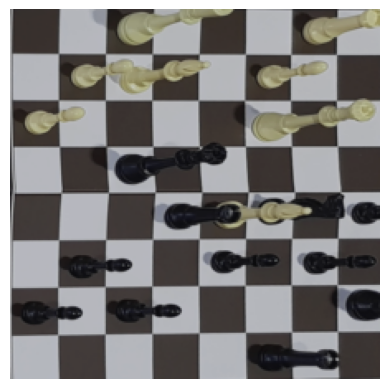

In [7]:
for batch in train_dataloader:
    # Get images of the batch and print their dimensions
    imgs = batch[0] # imgs have format [batch_size, channels, height, width]
    imgs = imgs.permute(0, 2, 3, 1)*torch.tensor([[[0.229, 0.224, 0.225]]]) + torch.tensor([[[0.485, 0.456, 0.406]]]) # changing format to [batch_size, height, width, channels] # also, use ImageNet normalization stats of mean and std dev
    print(imgs.shape)

    # Get labels of each image in the batch and print them
    labels = batch[1]
    print(labels)
    print(labels.shape)

    # Show first image of the batch
    plt.imshow(imgs[0])
    print("Piece count:", int(labels[0]))
    plt.axis('off')
    plt.show()

    break

## Defining the model

We will use a pre-trained ResNet50 network.

In [8]:
# Define model
resnet_model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# change head to 1 regression neuron
resnet_model.fc = torch.nn.Linear(resnet_model.fc.in_features, 1)
model = resnet_model
model.to(device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 226MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## Train the model

Define function to perform one iteration

In [9]:
def epoch_iter(dataloader, model, loss_fn, optimizer=None, is_train=True):
    if is_train:
      assert optimizer is not None, "When training, please provide an optimizer."

    num_batches = len(dataloader)

    if is_train:
      model.train() # put model in train mode
    else:
      model.eval()

    total_loss = 0.0
    preds = []
    labels = []

    with torch.set_grad_enabled(is_train):
      for batch, (X, y) in enumerate(tqdm(dataloader)):
          X, y = X.to(device), y.to(device).float()  # ensure labels are float for regression

          pred = model(X)  # Output shape: [batch_size, 1] or [batch_size]
          loss = loss_fn(pred.squeeze(), y)  # Squeeze to match dimensions

          if is_train:
              optimizer.zero_grad()
              loss.backward()
              optimizer.step()

          total_loss += loss.item() # IMPORTANT: call .item() to obtain the value of the loss WITHOUT the computational graph attached

          preds.extend(pred.squeeze().detach().cpu().numpy())
          labels.extend(y.detach().cpu().numpy())

    mae = mean_absolute_error(labels, preds)
    r2 = r2_score(labels, preds)

    return total_loss / num_batches, mae, r2

Define function to train a model

In [10]:
def train(model, model_name, num_epochs, train_dataloader, validation_dataloader, loss_fn, optimizer, patience=5, delta=0.01):
  train_history = {'loss': [], 'mae': [], 'r2': []}
  val_history = {'loss': [], 'mae': [], 'r2': []}

  best_val_loss = np.inf
  epochs_without_improvement = 0

  print("Start training...")
  for t in range(num_epochs):
      print(f"\nEpoch {t+1}")
      train_loss, train_mae, train_r2 = epoch_iter(train_dataloader, model, loss_fn, optimizer)
      print(f"Train loss: {train_loss:.3f} | MAE: {train_mae:.3f} | R²: {train_r2:.3f}")
      val_loss, val_mae, val_r2 = epoch_iter(validation_dataloader, model, loss_fn, is_train=False)
      print(f"Val loss: {val_loss:.3f} | MAE: {val_mae:.3f} | R²: {val_r2:.3f}")

      # save model when val loss improves
      if val_loss < best_val_loss - delta:
        best_val_loss = val_loss
        epochs_without_improvement = 0

        save_dict = {'model': model.state_dict(), 'optimizer': optimizer.state_dict(), 'epoch': t}
        torch.save(save_dict, f'{save_dir}{model_name}_best_model.pth')
      else:
        epochs_without_improvement += 1
        print(f"No improvement in val loss for {epochs_without_improvement} epoch(s).")

       # early stopping check
      if epochs_without_improvement >= patience:
        print("Early stopping triggered!")
        break
        
      # save latest model
      save_dict = {'model': model.state_dict(), 'optimizer': optimizer.state_dict(), 'epoch': t}
      torch.save(save_dict, f'{save_dir}{model_name}_latest_model.pth')

      # save training history for plotting purposes
      train_history["loss"].append(train_loss)
      train_history["mae"].append(train_mae)
      train_history["r2"].append(train_r2)

      val_history["loss"].append(val_loss)
      val_history["mae"].append(val_mae)
      val_history["r2"].append(val_r2)

  print("Finished")
  return train_history, val_history

# assumes that the first layers are already frozen in the model provided
def train_two_stage(model, model_name, num_epochs_stage1, num_epochs_stage2,
                    train_dataloader, validation_dataloader, loss_fn,
                    optimizer_stage1, optimizer_stage2, patience, delta):

    # === Stage 1: Assumed last layers are in fc field ===

    # Freeze all layers
    for param in model.parameters():
      param.requires_grad = False

    # Unfreeze only the final classification layer (fc)
    for param in model.fc.parameters():
      param.requires_grad = True

    print("Stage 1: Training head only...")
    train_history_1, val_history_1 = train(model, model_name + '_stage1', num_epochs_stage1,
                                           train_dataloader, validation_dataloader, loss_fn, optimizer_stage1, patience, delta)

    # load best model from stage 1
    checkpoint = torch.load(f'{save_dir}{model_name}_stage1_best_model.pth')
    model.load_state_dict(checkpoint['model'])

    # === Stage 2: Fine-tune entire model ===
    for param in model.parameters():
        param.requires_grad = True

    print("Stage 2: Fine-tuning entire model...")
    train_history_2, val_history_2 = train(model, model_name + '_stage2', num_epochs_stage2,
                                           train_dataloader, validation_dataloader, loss_fn, optimizer_stage2, patience, delta)

    return train_history_1, val_history_1, train_history_2, val_history_2


Define loss, optimizer and train the model

In [11]:
model_name = 'altered_regression_resnet50_unbalanced'

# Define loss function
loss_fn = nn.MSELoss()

# define learning rate and number of epochs for each stage
# Stage 1: Train only the head
num_epochs_stage1 = 10
lr_stage1 = 1e-3

# Stage 2: Fine-tune entire model
num_epochs_stage2 = 50 # should be 50
lr_stage2 = 1e-4  # lower to avoid overwriting pretrained features

# define optimizers
# Stage 1 optimizer (head only) # could also be SGD, but this one converges faster
# including frozen layers in the optimizer wastes both memory and computational resources since those parameters won’t be updated, so ignore them in the optimizer
optimizer_stage1 = torch.optim.AdamW(filter(lambda p: p.requires_grad, resnet_model.parameters()), lr=lr_stage1)

# Stage 2 optimizer (all layers)
optimizer_stage2 = torch.optim.AdamW(resnet_model.parameters(), lr=lr_stage2)

patience = 10 # number of epochs with no improvement after which training will be stopped, aka early stopping
delta = 1e-3  # minimum change to qualify as an improvement

train_history_1, val_history_1, train_history_2, val_history_2 = train_two_stage(resnet_model, model_name, num_epochs_stage1, num_epochs_stage2, train_dataloader, valid_dataloader, loss_fn, optimizer_stage1, optimizer_stage2, patience, delta)


Stage 1: Training head only...
Start training...

Epoch 1


100%|██████████| 91/91 [00:20<00:00,  4.48it/s]


Train loss: 240.357 | MAE: 13.071 | R²: -3.361


100%|██████████| 21/21 [00:03<00:00,  6.46it/s]


Val loss: 140.194 | MAE: 9.196 | R²: -0.868

Epoch 2


...

Val loss: 1.490 | MAE: 0.969 | R²: 0.980
No improvement in val loss for 9 epoch(s).

Epoch 48


100%|██████████| 91/91 [00:19<00:00,  4.68it/s]


Train loss: 0.528 | MAE: 0.576 | R²: 0.990


100%|██████████| 21/21 [00:02<00:00,  7.49it/s]

Val loss: 1.570 | MAE: 0.961 | R²: 0.979
No improvement in val loss for 10 epoch(s).
Early stopping triggered!
Finished


## Analyse training evolution

Plot loss and accuracy throughout training on train and validation data

In [12]:
def plotTrainingHistory(train_history_1, val_history_1, train_history_2, val_history_2):
    train_history = {
        'loss': train_history_1['loss'] + train_history_2['loss'],
        'mae': train_history_1['mae'] + train_history_2['mae'],
        'r2': train_history_1['r2'] + train_history_2['r2']
    }
    val_history = {
        'loss': val_history_1['loss'] + val_history_2['loss'],
        'mae': val_history_1['mae'] + val_history_2['mae'],
        'r2': val_history_1['r2'] + val_history_2['r2']
    }

    split_index = len(train_history_1['loss']) -1

    plt.figure(figsize=(10, 6))

    plt.subplot(3, 1, 1)
    plt.title('Loss (MSE)')
    plt.plot(train_history['loss'], label='Train')
    plt.plot(val_history['loss'], label='Validation')
    plt.axvline(split_index, linestyle=':', color='grey', label='Stage Switch')
    plt.legend()

    plt.subplot(3, 1, 2)
    plt.title('Mean Absolute Error (MAE)')
    plt.plot(train_history['mae'], label='Train')
    plt.plot(val_history['mae'], label='Validation')
    plt.axvline(split_index, linestyle=':', color='grey')
    plt.legend()

    plt.subplot(3, 1, 3)
    plt.title('R² Score')
    plt.plot(train_history['r2'], label='Train')
    plt.plot(val_history['r2'], label='Validation')
    plt.axvline(split_index, linestyle=':', color='grey')
    plt.legend()

    plt.tight_layout()
    plt.show()

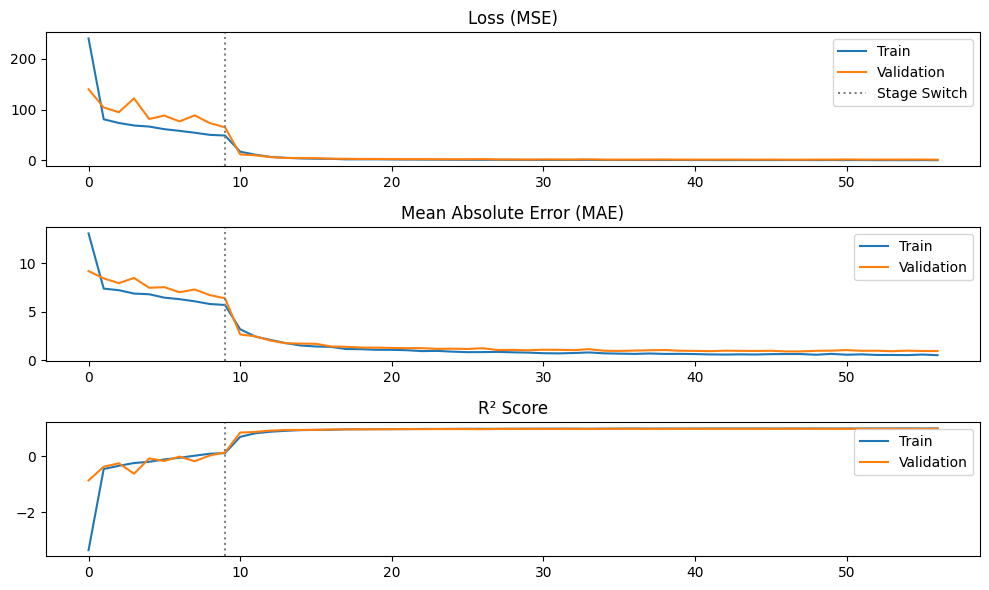

In [13]:
plotTrainingHistory(train_history_1, val_history_1, train_history_2, val_history_2)

## Test the model

Load best model 

In [14]:
# model 
model_name = 'altered_regression_resnet50_unbalanced'

# loss function
loss_fn = nn.MSELoss()

resnet_model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
resnet_model.fc = torch.nn.Linear(resnet_model.fc.in_features, 1)
model = resnet_model
model.to(device)

# load model, default to stage 2 best model
model_path = f'{save_dir}{model_name}.pth' 
if not os.path.exists(model_path):
    model_path = f'{save_dir}{model_name}_stage2_best_model.pth'

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"

checkpoint = torch.load(model_path, map_location=device)

model.load_state_dict(checkpoint['model'])

<All keys matched successfully>

Evaluate the model in the test set

In [15]:
def test_iter_with_metrics(dataloader, model, loss_fn, optimizer=None, is_train=True):
    if is_train:
      assert optimizer is not None, "When training, please provide an optimizer."

    num_batches = len(dataloader)

    if is_train:
      model.train() # put model in train mode
    else:
      model.eval()

    total_loss = 0.0
    preds = []
    labels = []

    with torch.set_grad_enabled(is_train):
      for batch, (X, y) in enumerate(tqdm(dataloader)):
          X, y = X.to(device), y.to(device).float()  # ensure labels are float for regression

          pred = model(X)  # Output shape: [batch_size, 1] or [batch_size]
          loss = loss_fn(pred.squeeze(), y)  # Squeeze to match dimensions

          if is_train:
              optimizer.zero_grad()
              loss.backward()
              optimizer.step()

          total_loss += loss.item() # IMPORTANT: call .item() to obtain the value of the loss WITHOUT the computational graph attached

          preds.extend(pred.squeeze().detach().cpu().numpy())
          labels.extend(y.detach().cpu().numpy())

    # round predictions, treat as accuracy metrics
    preds_rounded = np.round(preds)
    preds_rounded = np.clip(preds_rounded, 0, 32) # clip predictions to valid range of pieces (0-32)
    preds_rounded_int = preds_rounded.astype(int)

    labels_int = np.array(labels).astype(int)
    acc = np.mean(preds_rounded_int == labels_int)
    cm = confusion_matrix(labels_int, preds_rounded_int, labels=np.arange(33))  # confusion matrix for 0-32 pieces

    #regression metrics
    mae = mean_absolute_error(labels, preds)
    mae_rounded = mean_absolute_error(labels, preds_rounded)
    r2 = r2_score(labels, preds)

    return total_loss / num_batches, (mae, mae_rounded, r2, acc, cm)


In [16]:
test_loss, test_metrics = test_iter_with_metrics(test_dataloader, model, loss_fn, optimizer=None, is_train=False)
test_mae, test_mae_rounded, test_r2, test_acc, test_cm = test_metrics

100%|██████████| 20/20 [00:03<00:00,  6.50it/s]



Test Results:
Loss: 1.271
MAE: 0.914
MAE (rounded): 0.856
R² Score: 0.981
Exact Count Accuracy: 0.359


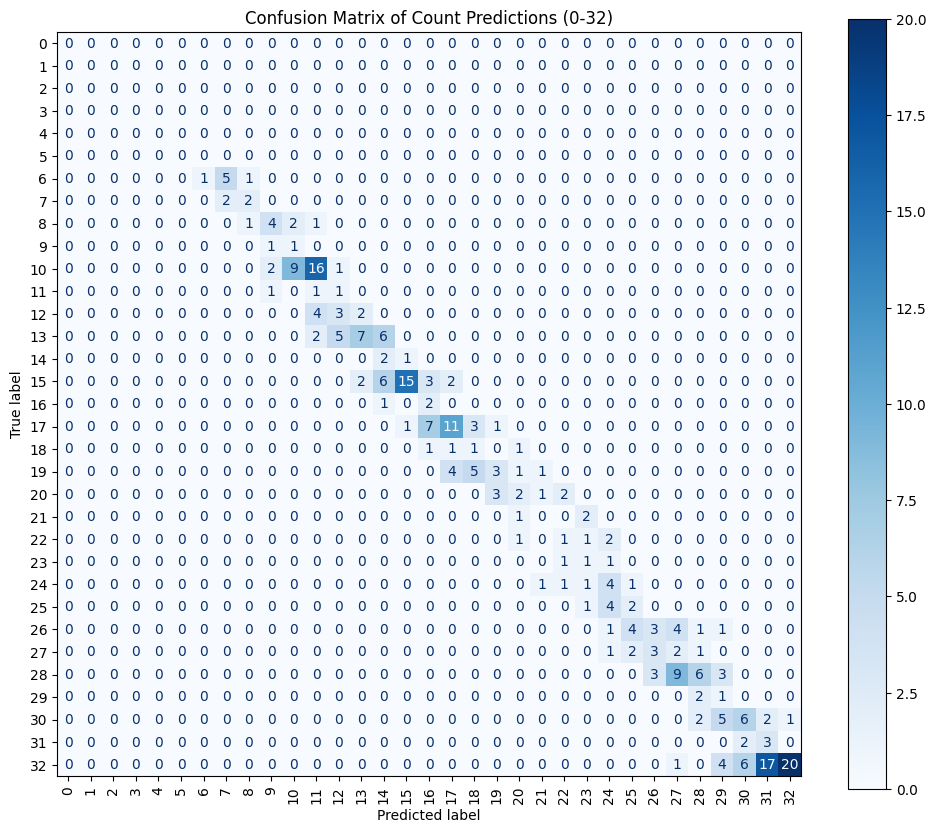

In [17]:
class_count = np.arange(33)  # 0 to 32 pieces

print(f"\nTest Results:")
print(f"Loss: {test_loss:.3f}")
print(f"MAE: {test_mae:.3f}")
print(f"MAE (rounded): {test_mae_rounded:.3f}")
print(f"R² Score: {test_r2:.3f}")
print(f"Exact Count Accuracy: {test_acc:.3f}")

#confusion matrix visualization with numbers
disp = ConfusionMatrixDisplay(confusion_matrix=test_cm, display_labels=class_count)
fig, ax = plt.subplots(figsize=(12, 10))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=90)
plt.title("Confusion Matrix of Count Predictions (0-32)")
plt.show()

#confusion matrix visualization with heatmap

# annot = np.where(test_cm > 0, test_cm.astype(str), "")

# plt.figure(figsize=(14, 12))
# sns.heatmap(test_cm, fmt='', cmap='Blues', xticklabels=class_count, yticklabels=class_count, cbar=True)

# plt.xlabel("Predicted Count")
# plt.ylabel("True Count")

# plt.title("Confusion Matrix of Count Predictions (0–32)")
# plt.xticks(rotation=90)
# plt.yticks(rotation=0)
# plt.tight_layout()
# plt.show()

In [18]:
#Save the training history as well
import json

# convert Numpy types to json serializable types
def json_default(obj):
    if isinstance(obj, (np.integer, np.floating)):
        return obj.item()
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    raise TypeError(f"Object of type {obj.__class__.__name__} is not JSON serializable")

with open(f'{save_dir}{model_name}_train_history_stage1.json', 'w') as f:
    json.dump(train_history_1, f, default=json_default)

with open(f'{save_dir}{model_name}_val_history_stage1.json', 'w') as f:
    json.dump(val_history_1, f, default=json_default)

with open(f'{save_dir}{model_name}_train_history_stage2.json', 'w') as f:
    json.dump(train_history_2, f, default=json_default)

with open(f'{save_dir}{model_name}_val_history_stage2.json', 'w') as f:
    json.dump(val_history_2, f, default=json_default)